# Día 4 · Cuaderno 10 — Programar con IA: prompts efectivos y descomposición

**Programar para enseñar — Python e IA generativa para Humanidades Digitales**
Formación docente para EH1023 · Pontificia Universidad Javeriana, Facultad de Ingeniería

*(Primer bloque del Día 4 — 2 horas)*

---

Ya sabes programar lo básico. Hoy aprenderás a **programar acompañado de una IA generativa**
(**TecGPT, Gemini o Copilot**, las herramientas autorizadas por el Tec) de forma **crítica y
metódica**. La idea central del día:

> **Un problema difícil se resuelve partiéndolo en una secuencia de pasos pequeños, y cada paso se
> le pide a la IA con un prompt corto.** Así pasamos de "captura los datos" a "procésalos" a
> "visualízalos", verificando en cada paso.


## 1. Cómo trabajaremos hoy

La IA **no vive dentro de este cuaderno**. Trabajaremos en dos ventanas:

1. En una ventana abres **Gemini, Copilot o TecGPT**.
2. Le escribes un **prompt corto** y te devuelve código.
3. **Copias** ese código a una celda de este cuaderno y lo **ejecutas**.
4. **Verificas**: ¿funcionó? ¿hace lo que pedí? Si no, iteras.

El ciclo es: **pedir → leer → pegar → ejecutar → verificar → iterar.**

> ⚠️ **Regla del curso:** la IA escribe el código, pero **tú tienes que entenderlo**. Si no puedes
> explicar qué hace una línea, pídele a la IA que te la explique antes de seguir. Esto es justo lo
> contrario de "depender ciegamente" de la IA.


## 2. La anatomía de un buen prompt: el método **CREA**

Un buen prompt no tiene que ser largo, sino **específico**. Para recordar qué incluir, usamos un
memotécnico fácil de enseñar:

> ## **CREA = Contexto + Rol + Expectativas + Acción**

| Letra | Qué responde | Qué incluir |
|---|---|---|
| **C — Contexto** | ¿Cuál es la situación? ¿sobre qué datos? | El problema, el público, el documento, el nivel, los antecedentes **y los datos de entrada** (su formato, solo un ejemplo de los datos no es necesario ni prudente incluir todos). |
| **R — Rol** | ¿Desde qué perspectiva quiero que responda? | Profesor, revisor, programador, editor, tutor, jurado, asesor técnico… |
| **E — Expectativas** | ¿Qué quiero recibir y con qué reglas? | Formato, profundidad, tono, extensión, idioma, ejemplos, tabla, rúbrica, código… **y las restricciones** (qué librería, simplicidad). |
| **A — Acción** | ¿Qué debe hacer exactamente? | Resumir, corregir, comparar, evaluar, redactar, explicar, convertir, generar, diagnosticar… |

**Prompt vago (evítalo):** *"hazme un análisis de datos"*.

**Prompt efectivo con CREA (corto pero completo):**
> *(Contexto)* "Tengo un CSV de obras literarias en esta URL `<url>`. *(Rol)* Actúa como
> instructor de Python para principiantes. *(Expectativas)* En español, con pandas, y comenta cada
> línea. *(Acción)* Cárgalo en un DataFrame y muéstrame las primeras filas."

> 💡 No hace falta que estén las cuatro letras siempre, ni en ese orden. **CREA** es una lista de
> verificación: si un prompt no funciona, revisa **qué letra te faltó**.


## 3. La metodología: una secuencia de prompts cortos

En lugar de pedir todo de golpe (*"analiza y grafica las obras literarias"*), partimos el problema en
**tres pasos**, cada uno con su prompt corto:

1. **Capturar** los datos → traerlos a un DataFrame.
2. **Procesar** → calcular lo que nos interesa.
3. **Visualizar** → convertirlo en un gráfico.

Cada paso es **pequeño, comprensible y verificable**. Si algo falla, sabes exactamente en qué paso.
Veámoslo con un ejemplo real.


## 4. Ejemplo guiado 1 — Obras literarias (capturar → procesar → visualizar)

### Paso 1 · Capturar

**Prompt corto para la IA:**
> *En Python con pandas, carga el CSV de esta URL en un DataFrame llamado `df` y muestra las primeras
> filas:*
> `https://raw.githubusercontent.com/calderonf/curso-python-humanidades-digitales/main/datos/obras_literarias.csv`

El código que la IA suele devolver (cópialo y ejecútalo):


In [1]:
import pandas as pd

# URL del archivo CSV
url = "https://raw.githubusercontent.com/calderonf/curso-python-humanidades-digitales/main/datos/obras_literarias.csv"

# Cargar el archivo CSV en un DataFrame
df = pd.read_csv(url)

# Mostrar las primeras filas del DataFrame
df.head()

,titulo,autor,anio,genero,paginas
0,Don Quijote de la Mancha,Miguel de Cervantes,1605,Novela,863
1,La vida es sueno,Pedro Calderon de la Barca,1635,Teatro,120
2,Cien anios de soledad,Gabriel Garcia Marquez,1967,Novela,471
3,Pedro Paramo,Juan Rulfo,1955,Novela,124
4,Rayuela,Julio Cortazar,1963,Novela,736


**Verifica:** ¿se cargó? ¿ves columnas como `titulo`, `autor`, `anio`, `genero`, `paginas`?
Si sí, el Paso 1 está listo. Pasamos al siguiente.

### Paso 2 · Procesar

**Prompt corto para la IA:**
> *Con ese DataFrame `df`, cuenta cuántas obras hay por `genero`, ordenadas de mayor a menor.*


In [2]:
conteo_por_genero = df['genero'].value_counts()
conteo_por_genero

genero
Novela    14
Cuento     5
Poesia     5
Teatro     3
Ensayo     2
Comic      1
Name: count, dtype: int64

**Verifica:** ¿los números tienen sentido? ¿suman el total de obras? Si sí, seguimos.

### Paso 3 · Visualizar — dos gráficas en un *subplot*

En el Día 3 varios preguntaron cómo poner **varias gráficas juntas**. Se hace con
`plt.subplots()`, que crea **una figura** con una rejilla de **ejes** (cada eje, un `ax`, es una
gráfica). Pedimos `plt.subplots(1, 2)` → **1 fila y 2 columnas**, y dibujamos en `axes[0]`
(izquierda) y `axes[1]` (derecha). Ojo: sobre un `ax` se usa `ax.set_title(...)` y
`ax.set_xlabel(...)` (con `set_`), no `plt.title(...)`.

**Prompt corto para la IA (usando CREA):**
> *(Rol)* Como instructor de Python para principiantes, *(Acción)* haz con matplotlib un **subplot
> de 1 fila y 2 columnas**: *(Contexto + Expectativas)* a la **izquierda**, un gráfico de barras del
> conteo de obras por género; a la **derecha**, un histograma de la columna `paginas`. Ponles título
> y etiquetas en español y usa `tight_layout()`.


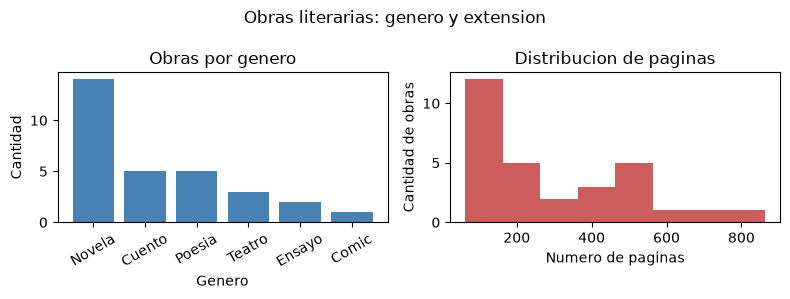

In [10]:
import matplotlib.pyplot as plt

conteo = df["genero"].value_counts()

# plt.subplots(filas, columnas) -> una figura y una rejilla de ejes.
# Aqui: 1 fila y 2 columnas, asi que 'axes' tiene dos ejes: axes[0] y axes[1].
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Grafica 1 (izquierda): barras de obras por genero
axes[0].bar(conteo.index, conteo.values, color="steelblue")
axes[0].set_title("Obras por genero")
axes[0].set_xlabel("Genero")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=30)

# Grafica 2 (derecha): histograma del numero de paginas
axes[1].hist(df["paginas"], bins=8, color="indianred")
axes[1].set_title("Distribucion de paginas")
axes[1].set_xlabel("Numero de paginas")
axes[1].set_ylabel("Cantidad de obras")

fig.suptitle("Obras literarias: genero y extension")  # titulo general de la figura
plt.tight_layout()
plt.show()


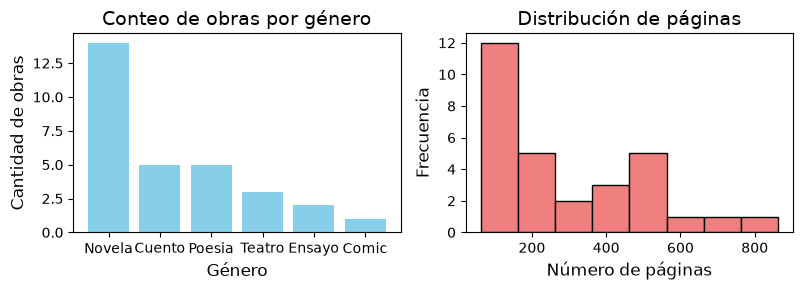

In [11]:
# Contar obras por género
conteo_por_genero = df['genero'].value_counts()

# Crear la figura y los subplots (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Gráfico de barras - Conteo por género
axes[0].bar(conteo_por_genero.index, conteo_por_genero.values, color='skyblue')
axes[0].set_title('Conteo de obras por género', fontsize=14)
axes[0].set_xlabel('Género', fontsize=12)
axes[0].set_ylabel('Cantidad de obras', fontsize=12)

# Histograma - Páginas
axes[1].hist(df['paginas'], bins=8, color='lightcoral', edgecolor='black')
axes[1].set_title('Distribución de páginas', fontsize=14)
axes[1].set_xlabel('Número de páginas', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)

# Ajustar el diseño para evitar superposiciones
plt.tight_layout()

# Mostrar la gráfica
plt.show()

🎉 Con **tres prompts cortos** construiste un análisis completo. Fíjate en lo importante: **no
pediste todo de una vez**; encadenaste pasos pequeños y verificaste cada uno. Esa es la metodología.


## 5. Verificar el código de la IA (imprescindible)

La IA se equivoca. Antes de confiar en su código, hazte cuatro preguntas:

1. **¿Corre sin errores?** Si sale un error rojo, léelo: suele decir la causa dale el error y el numero de linea a la IA para que tenga contexto.
2. **¿Hace lo que pedí?** Que no dé error no significa que haga lo correcto.
3. **¿Inventó algo?** A veces usa librerías que no existen o funciones equivocadas (*alucinaciones*).
4. **¿Lo entiendo?** Si no, pide: *"explícame esta línea"*.

> 🧭 **Nota para docentes.** Esta es la respuesta a la preocupación más repetida en la encuesta:
> que los estudiantes **dependan demasiado de la IA**. La salida no es prohibirla, sino enseñar a
> **verificarla**. Un estudiante que sabe revisar y explicar el código que la IA le dio, está
> aprendiendo; uno que solo copia y pega, no.


## 6. Ejemplo guiado 2 — Frecuencia de palabras en un texto

Mismo método, ahora con **texto** (uno de los intereses más mencionados en la encuesta). Tres pasos,
tres prompts cortos.

### Paso 1 · Capturar
> *En Python, descarga el texto de esta URL y guárdalo en una variable `texto`:*
> `https://raw.githubusercontent.com/calderonf/curso-python-humanidades-digitales/main/datos/fragmento_literario.txt`


In [15]:
import urllib.request

url = "https://raw.githubusercontent.com/calderonf/curso-python-humanidades-digitales/main/datos/fragmento_literario.txt"
texto = urllib.request.urlopen(url).read().decode("utf-8")
print(texto)

En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho
tiempo que vivia un hidalgo de los de lanza en astillero, adarga antigua,
rocin flaco y galgo corredor. Una olla de algo mas vaca que carnero,
salpicon las mas noches, duelos y quebrantos los sabados, lentejas los
viernes, algun palomino de anadidura los domingos, consumian las tres
partes de su hacienda. El resto della concluian sayo de velarte, calzas de
velludo para las fiestas, con sus pantuflos de lo mesmo, y los dias de
entresemana se honraba con su vellori de lo mas fino.



### Paso 2 · Procesar
> *Cuenta las 10 palabras más frecuentes del texto, en minúsculas y sin signos de puntuación.*


In [13]:
from collections import Counter

limpio = texto.lower().replace(",", "").replace(".", "")
palabras = limpio.split()
frecuencias = Counter(palabras)
top10 = frecuencias.most_common(10)
print(top10)

[('de', 12), ('los', 5), ('y', 3), ('mas', 3), ('las', 3), ('en', 2), ('un', 2), ('no', 2), ('que', 2), ('su', 2)]


### Paso 3 · Visualizar
> *Haz un gráfico de barras con esas 10 palabras y sus frecuencias.*


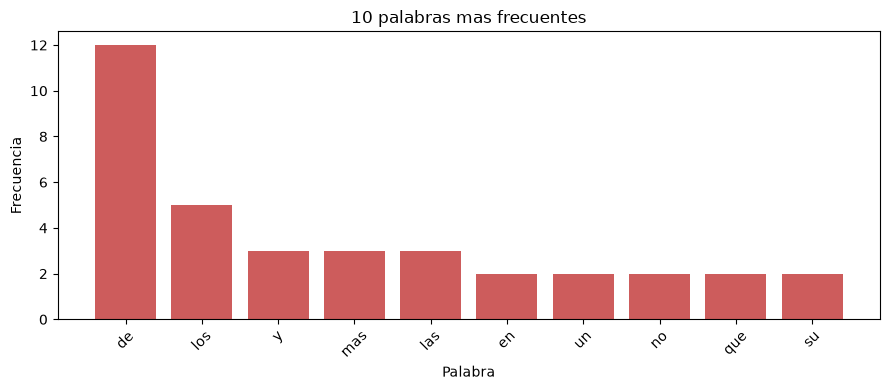

In [14]:
import matplotlib.pyplot as plt

palabras = [par[0] for par in top10]
frec = [par[1] for par in top10]

plt.figure(figsize=(9, 4))
plt.bar(palabras, frec, color="indianred")
plt.title("10 palabras mas frecuentes")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> 💡 Notarás que arriba aparecen palabras como *de*, *la*, *no*... Son **palabras vacías**
> (*stopwords*). Un cuarto prompt natural sería: *"quita las palabras vacías del español antes de
> contar"*. ¡Así se ve cómo la secuencia de prompts se sigue refinando paso a paso!


## 7. Tu turno: practica la metodología

**Actividad A (guiada).** Vuelve al Ejemplo 1 y agrega un **cuarto paso**. Escribe tú el prompt corto
para pedirle a la IA un gráfico del **promedio de páginas por género**. Pégalo, ejecútalo y verifícalo.


In [ ]:
# Pega aqui el codigo que te dio la IA para el paso 4:


**Actividad B (diseña tu secuencia).** Piensa en un mini-proyecto de tu área y escríbelo como una
**secuencia de 3 prompts cortos** (capturar / procesar / visualizar). Todavía no lo ejecutes: hoy el
objetivo es **descomponer bien el problema**. Usa esta plantilla:


**Plantilla — mi secuencia de prompts**

- **Mi pregunta o proyecto:**
- **Prompt 1 (capturar):**
- **Prompt 2 (procesar):**
- **Prompt 3 (visualizar):**
- **¿Cómo verificaré cada paso?**


> 🧭 **Nota para docentes.** La habilidad que más vale la pena enseñar aquí **no es escribir
> código**, sino **descomponer un problema** en pasos pequeños y **verificar** cada uno. Un estudiante
> que sabe partir el problema sabrá guiar a la IA; uno que no, se perderá por más potente que sea la
> herramienta. Y recuerda: **ustedes delimitan el taller**: un primer proyecto con un pipeline de 3
> pasos sobre datos ya listos es alcanzable; pedir scraping + modelo + dashboard el primer día, no.


---

## Cierre del bloque

Aprendiste el método del día: **descomponer** un problema difícil en una **secuencia de prompts
cortos** (capturar → procesar → visualizar) y **verificar** cada paso. Lo practicaste con datos
tabulares y con texto.

### Esta tarde (segundo bloque del Día 4)

Veremos **más pipelines** inspirados en los proyectos que ustedes mencionaron en la encuesta, y cómo
llevar esto al aula: **políticas de uso de IA** y una **rúbrica** para evaluar trabajos hechos con
apoyo de IA.

> Guarda tu trabajo con **Archivo → Guardar una copia en Drive**.
